# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import gc
from tqdm import tqdm
from sklearn.model_selection import train_test_split

tqdm.pandas()

gc.collect()
torch.cuda.empty_cache()

# Loading the dataset

In [2]:
df = pd.read_csv('../datasets/HC/lesions.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lesionId         2526 non-null   int64  
 1   createdAt        2526 non-null   object 
 2   bodyPart         2511 non-null   object 
 3   description      2504 non-null   object 
 4   clinicDiagnosis  2512 non-null   object 
 5   examRequired     2526 non-null   bool   
 6   examResult       116 non-null    object 
 7   examDate         339 non-null    object 
 8   phototype        2526 non-null   object 
 9   imageFull        2517 non-null   object 
 10  imageCropped     2517 non-null   object 
 11  platform         2488 non-null   object 
 12  hasCoordinates   2526 non-null   bool   
 13  lesionX          2176 non-null   float64
 14  lesionY          2176 non-null   float64
 15  lesionRadius     2154 non-null   float64
dtypes: bool(2), float64(3), int64(1), object(10)
memory usage: 2

In [ ]:
df = df.dropna(subset=['clinicDiagnosis', 'imageCropped'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2507 entries, 0 to 2525
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lesionId         2507 non-null   int64  
 1   createdAt        2507 non-null   object 
 2   bodyPart         2504 non-null   object 
 3   description      2499 non-null   object 
 4   clinicDiagnosis  2507 non-null   object 
 5   examRequired     2507 non-null   bool   
 6   examResult       116 non-null    object 
 7   examDate         339 non-null    object 
 8   phototype        2507 non-null   object 
 9   imageFull        2507 non-null   object 
 10  imageCropped     2507 non-null   object 
 11  platform         2469 non-null   object 
 12  hasCoordinates   2507 non-null   bool   
 13  lesionX          2171 non-null   float64
 14  lesionY          2171 non-null   float64
 15  lesionRadius     2149 non-null   float64
dtypes: bool(2), float64(3), int64(1), object(10)
memory usage: 298.7+

# Preprocessing the data

In [ ]:
df = df.drop(columns=['lesionId', 'description', 'createdAt', 'phototype', 'examDate', 'platform', 'examRequired', 'examResult', 'imageFull', 'hasCoordinates', 'lesionX', 'lesionY', 'lesionRadius'])
print(df.head())

                          bodyPart                 clinicDiagnosis  \
0  Face Posterior do Braço Direito  Sugestivo de neoplasia maligna   
1          Região Temporal Direita                             BCC   
2          Região Geniana Esquerda                             BCC   
3               Região Periorbital                              NV   
4       Região Zigomática Esquerda                              NV   

                               imageCropped  
0  f650ce0a-928e-4cb3-a201-8187ffc300bc.png  
1  4169e29c-bdd8-483d-9f41-b326efa61595.png  
2  a2ed37fe-2234-477f-8d12-4cda006e5f89.png  
3  c6d82094-8d48-4ff1-a3a9-0f288d3c9e66.png  
4  fe9cd23a-8222-409b-8f37-bbec20d04044.png  


## Separating labels in malignant and benign

In [5]:
print(df['clinicDiagnosis'].value_counts())

clinicDiagnosis
BKL                                                  461
NV                                                   394
AKIEC                                                359
BCC                                                  356
Melanose solar                                       196
                                                    ... 
Melanócito solar                                       1
Carcinoma espinocelular in situ (doença de Bowen)      1
Fibroma                                                1
Queratose seborreica tipo plana                        1
Dermatite                                              1
Name: count, Length: 257, dtype: int64


In [6]:
print("All labels: ")
print(df['clinicDiagnosis'].unique())

All labels: 
['Sugestivo de neoplasia maligna' 'BCC' 'NV' 'Queratose seborreica '
 'AKIEC' 'Nevo intradérmico ' 'SCC'
 'Carcinoma espinocelular in situ (doença de Bowen)' 'Verruga plana'
 'Verruga' 'síndrome de Favre-Racouchot' 'Carcinoma espinocelular in situ'
 'Queratose seborreica tipo plana' 'DF' 'Doença de Bowen' 'MEL'
 'Nevo melanocítico' 'Queratose seborreica' 'Nevo displásico ' 'Queloide '
 'Prurigo biopsiante' 'Vitiligo' 'Queloide' 'Nevo displásico'
 'Queratose seborreia ' 'Nevo intradérmico' 'Confluência CEC e CBC'
 'Dermatose papulosa nigra' 'Queratose seborreica não pigmentada'
 'Melanose solar' 'Melanoníquia estriada ' 'Ceratose seborreica '
 'Psoríase ' 'Lúpus eritematoso sistêmico ' 'VASC' 'Corno Cutâneo'
 'Nevo Intradérmico' 'BKL' 'Queratose liquenoide' 'Melanose Solar'
 'Esporotricose' 'Pólipo fibroepitelial ou molusco pêndulo '
 'Nódulo benigno ' 'Fibroma mole' 'Dermatose papulosa nigrica' 'Verruga '
 'Melanoníquia por Eczema de Contato' 'Acrocordon' 'Nevo rubi'
 'Nev

In [ ]:
malignant_keywords = [
    'melanoma',
    'maligno',
    'carcinoma',
    'espinocelular',
    'basocelular',
    'akiec',
    'maligna',
    'cec',
    'doença de bowen',
    'neoplasia',
    'mel',
    'bcc',
    'scc',
    'cbc'
]

In [ ]:
def map_diagnosis(diagnosis):
    diagnosis_lower = diagnosis.strip().lower()
    for keyword in malignant_keywords:
        if keyword in diagnosis_lower:
            return 'malignant'
    return 'benign'

In [ ]:
df['benign_malignant'] = df['clinicDiagnosis'].apply(map_diagnosis)

df = df.drop(columns=['clinicDiagnosis'])

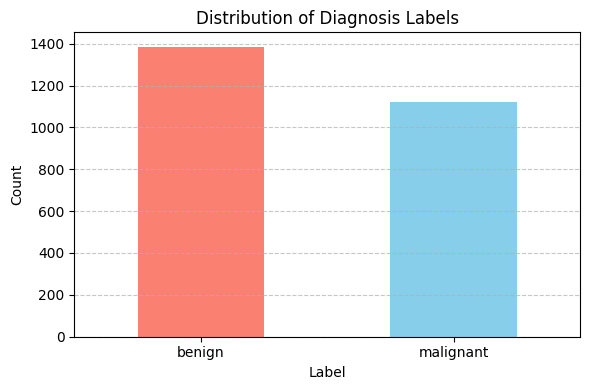


Category distribution:
benign_malignant
benign       1385
malignant    1122
Name: count, dtype: int64


In [ ]:
label_counts = df['benign_malignant'].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['salmon', 'skyblue'])

plt.title('Distribution of Diagnosis Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nCategory distribution:")
print(df['benign_malignant'].value_counts())

## Translate dataset rows to english

In [11]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
cache_dir = "../models"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    cache_dir=cache_dir
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    cache_dir=cache_dir
)

tokenizer.padding_side = "left"

In [12]:
def translate_batch(texts, batch_size=128):
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = texts[i:i + batch_size]
        
        messages_batch = [
            [
                {"role": "system", "content": "You are a medical helpful assistant that translate dermatological texts from brazilian portuguese to english."},
                {"role": "user", "content": f"Translate the following portuguese medical text into english. Return only the translated text: {t}"}
            ]
            for t in batch
        ]
        
        prompts = tokenizer.apply_chat_template(
            messages_batch,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=128)

        generated_ids = [
            output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, outputs)
        ]

        translations.extend(tokenizer.batch_decode(generated_ids, skip_special_tokens=True))

    return translations

In [13]:
df.rename(columns={
    'imageCropped': 'img_id'
}, inplace=True)

df['bodyPart'] = translate_batch(df['bodyPart'].tolist())

Translating: 100%|██████████| 20/20 [00:41<00:00,  2.09s/it]


# Splitting the data on three dataframes

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['benign_malignant'],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['benign_malignant'],
    random_state=42
)

# Balance analysis

In [ ]:
def print_class_distribution(df, name):
    counts = df['benign_malignant'].value_counts()
    return counts

In [ ]:
def plot_class_distribution(counts, split_name):
    labels = counts.index.tolist()
    values = counts.values
    percentages = (counts / counts.sum()) * 100

    plt.figure(figsize=(6,4))
    bars = plt.bar(labels, values, color=['skyblue', 'salmon'])
    
    plt.ylim(0, max(values) * 1.1)

    for bar, value, pct in zip(bars, values, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01,
                 f"{value} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

    plt.title(f'Class distribution - {split_name}')
    plt.ylabel('Number of samples')
    plt.xlabel('Class')
    plt.show()

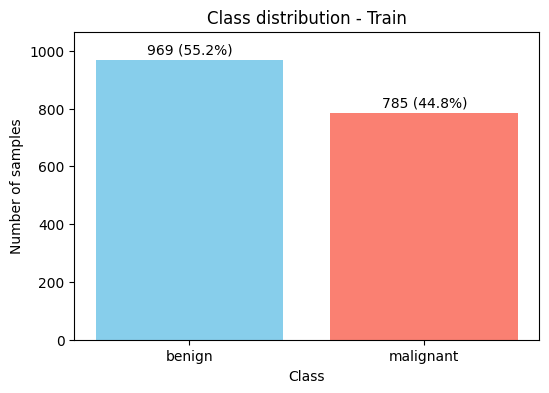

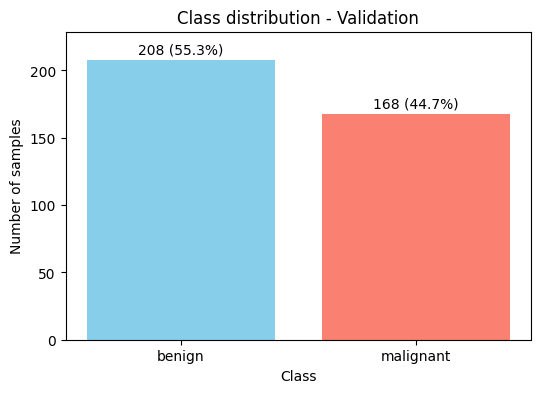

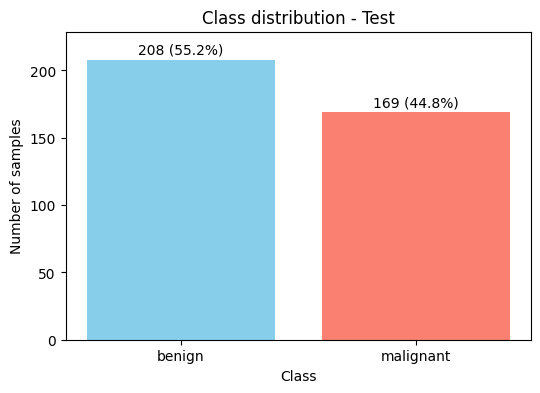

In [ ]:
train_counts = print_class_distribution(train_df, "Train")
val_counts = print_class_distribution(valid_df, "Validation")
test_counts = print_class_distribution(test_df, "Test")

train_count = len(train_df)
val_count = len(valid_df)
test_count = len(test_df)
total_count = train_count + val_count + test_count

plot_class_distribution(train_counts, "Train")
plot_class_distribution(val_counts, "Validation")
plot_class_distribution(test_counts, "Test")

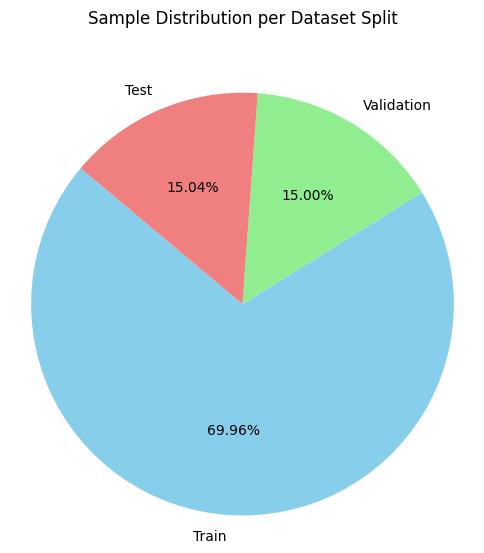


Total number of samples per split:
Train: 1754
Validation: 376
Test: 377


In [ ]:
split_labels = ['Train', 'Validation', 'Test']
split_counts = [train_count, val_count, test_count]

plt.figure(figsize=(6, 6))
plt.pie(
    split_counts,
    labels=split_labels,
    autopct='%1.2f%%',
    colors=['skyblue', 'lightgreen', 'lightcoral'],
    startangle=140
)
plt.title('Sample Distribution per Dataset Split\n\n')
plt.axis('equal')
plt.show()

print("\nTotal number of samples per split:")
print(f"Train: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")

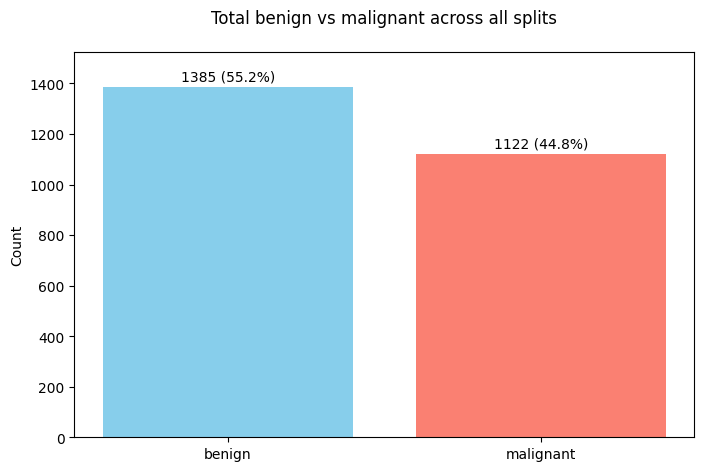

In [ ]:
total_counts = train_counts.add(val_counts, fill_value=0).add(test_counts, fill_value=0).astype(int)
total_percentages = (total_counts / total_counts.sum()) * 100

labels = total_counts.index.tolist()
counts = total_counts.values
percentages = total_percentages.values

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=['skyblue', 'salmon'])

plt.ylim(0, max(counts) * 1.1)

for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01,
             f"{count} ({pct:.1f}%)",
             ha='center', va='bottom', fontsize=10)

plt.title("Total benign vs malignant across all splits\n")
plt.ylabel("Count")
plt.show()

# Saving results:

In [18]:
train_df.to_csv('../datasets/HC/train_metadata.csv', index=False, encoding='utf-8')
valid_df.to_csv('../datasets/HC/validation_metadata.csv', index=False, encoding='utf-8')
test_df.to_csv('../datasets/HC/test_metadata.csv', index=False, encoding='utf-8')